# Transferring of Neuronal cell states from the Gut Cell Atlas (Elementaite, 2021) to Remapped Data Using the `scVI - scANVI` Pipeline

**Developed by:** Anna Maguza\
**Affiliation:** Faculty of Medicine, Würzburg University\
**Creation date:** 3rd February 2025\
**Last modified date:** 3rd February 2025

#### **Objective**

This notebook outlines the process for transferring neuronal cell states annotations from the Gut Cell Atlas (Elementaite, 2021) to a series of remapped datasets using the `scVI - scANVI` pipeline. Our goal is to ensure consistent annotation of cell types across studies and to identify cells requiring manual validation.\
We analyze the confidence scores produced by `scANVI` to identify cells with low classification certainty. These cells are flagged for potential manual review and validation to ensure the accuracy of the annotations.\
Finally, we evaluate the performance of the `scVI` and `scANVI` models using `scIB` metrics. This step helps quantify the quality of the integration, classification, and batch correction.

## Import packages

In [70]:
import scvi
import torch
import anndata
import warnings
import numpy as np
import scanpy as sc
import anndata
import pandas as pd
import plotnine as p
import matplotlib.pyplot as plt
import seaborn as sns
from scib_metrics.benchmark import Benchmarker

import json
from datetime import datetime

## Setup working environment

In [71]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi = 180, color_map = 'magma_r', dpi_save = 300, vector_friendly = True, format = 'svg')

In [72]:
warnings.simplefilter(action = 'ignore')
scvi.settings.seed = 1712
%config InlineBackend.print_figure_kwargs = {'facecolor' : "w"}
%config InlineBackend.figure_format = 'retina'
torch.set_float32_matmul_precision('medium')

Seed set to 1712


In [73]:
arches_params = dict(
    use_layer_norm = "both",
    use_batch_norm = "none",
    encode_covariates = True,
    dropout_rate = 0.2,
    n_layers = 3,
)

In [74]:
def X_is_raw(adata):
    return np.array_equal(adata.X.sum(axis=0).astype(int), adata.X.sum(axis=0))

In [75]:
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')

## Upload data

In [76]:
adata = sc.read_h5ad('data/gut_data/gut_hs_all_datasets_scVI_scANVI_celltypes_AM_10012025_100142_raw.h5ad')
adata

AnnData object with n_obs × n_vars = 402343 × 43704
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protoc

In [77]:
adata.obs['celltype'] = adata.obs['C_scANVI']

In [78]:
adata = adata[adata.obs['celltype'] == 'Neuronal']

In [79]:
del adata.obs['_scvi_batch'], adata.obs['_scvi_labels'], adata.obs['C_scANVI'], adata.obs['confidence_score']
del adata.obsm['X_scANVI'], adata.obsm['X_scVI'], adata.obsm['X_pca'], adata.obsm['umap_uncorrected'], adata.obsm['_scvi_extra_categorical_covs']
del adata.obsm['X_umap_qc']

In [80]:
X_is_raw(adata)

True

## Prepare observations

In [81]:
adata.obs['Protocol REF'] = adata.obs['Protocol REF'].cat.add_categories('Unknown')
adata.obs['Protocol REF'] = adata.obs['Protocol REF'].replace(['  '], 'Unknown')

In [82]:
adata.obs['Protocol REF'].value_counts()

Protocol REF
P-MTAB-101781    14688
P-MTAB-95162      5605
P-MTAB-100897     1272
P-MTAB-102913      278
P-MTAB-100978       15
Unknown              5
Name: count, dtype: int64

In [83]:
adata.obs['Performer'].value_counts()

Performer
University of Michigan DNA Sequencing core                                                           14688
Wellcome Sanger Institute                                                                             5610
Rasa Elmentaite, Kylie James                                                                          1272
University of Michigan Advanced Genomics Core                                                          278
Wellcome Sanger Institute Cellular Generation and Phenotyping teaml, Kylie James, Rasa Elmentaite       15
Name: count, dtype: int64

In [84]:
adata.obs['library_construction'] = adata.obs['library_construction'].astype(str)
adata.obs['LIBRARY_LAYOUT'] = adata.obs['LIBRARY_LAYOUT'].astype(str)
adata.obs['library_construnction_and_layout'] = adata.obs['library_construction'] + '_' + adata.obs['LIBRARY_LAYOUT']
adata.obs['library_construnction_and_layout'].value_counts()

library_construnction_and_layout
10xV2_SINGLE    8225
10xV2_PAIRED    6897
10xV3_SINGLE    6463
10xV3_PAIRED     278
Name: count, dtype: int64

In [85]:
adata.obs['donor_id'] = adata.obs['donor_id'].cat.add_categories('cell_culture')
adata.obs['donor_id'] = adata.obs['donor_id'].replace(['nan'], 'cell_culture')

+ Delete samples with less than 10 cells

In [86]:
cell_counts = adata.obs['sample_id'].value_counts()
samples_to_remove = cell_counts[cell_counts < 10].index
adata = adata[~adata.obs['sample_id'].isin(samples_to_remove)].copy()

+ Delete not mesenchymal cell states 

In [87]:
adata.obs['Integrated_05'].value_counts()

Integrated_05
Unknown                 15915
ENCC/glia Progenitor     1501
cycling ENCC/glia        1353
Neuroblast                635
Branch B1 (eMN)           588
Branch A1 (iMN)           505
Glia 3 (BCAN+)            306
Glia 1 (DHH+)             220
cycling neuroblast        175
Branch A2 (IPAN/IN)       140
Differentiating glia      132
Branch B2 (eMN)           130
Glia 2 (ELN+)             112
Branch A3 (IPAN/IN)        50
Branch A4 (IN)             40
Branch B3 (IPAN)           13
TA                          1
Name: count, dtype: int64

In [88]:
adata = adata[adata.obs['Integrated_05'] != 'TA']

+ Relabel into broader annotation

In [99]:
cell_state_mapping = {
    'ENCC/glia Progenitor': 'Progenitor',
    'cycling ENCC/glia': 'Progenitor',
    'Neuroblast': 'Neuroblast',
    'cycling neuroblast': 'Neuroblast',
    'Branch B1 (eMN)': 'Branch B',
    'Branch B2 (eMN)': 'Branch B',
    'Branch A1 (iMN)': 'Branch A',
    'Branch A2 (IPAN/IN)': 'Branch A',
    'Branch A3 (IPAN/IN)': 'Branch A',
    'Branch A4 (IN)': 'Branch A',
    'Branch B3 (IPAN)': 'Branch B',
    'Glia 1 (DHH+)': 'Glia',
    'Glia 2 (ELN+)': 'Glia',
    'Glia 3 (BCAN+)': 'Glia',
    'Differentiating glia': 'Glia',
    'Unknown': 'Unknown',
}

In [100]:
adata.obs['cell_states'] = adata.obs['Integrated_05'].map(cell_state_mapping)

+ Delete doublets

In [91]:
adata = adata[adata.obs['predicted_doublets'] != 'True']

+ Fix issue with Boolean None

In [92]:
adata.obs['cell_type'] = adata.obs['cell_type'].replace(['  '], 'unsorted')
adata.obs['cell_type'] = adata.obs['cell_type'].replace(['epithelial cell'], 'intestinal epithelial cell')
adata.obs['cell_type'] = adata.obs['cell_type'].cat.remove_unused_categories()
adata.obs['cell_type'] = adata.obs['cell_type'].fillna('unsorted')

In [93]:
adata.obs['cluster_passed_qc'] = adata.obs['cluster_passed_qc'].astype(str)
adata.obs['cluster_passed_qc'] = adata.obs['cluster_passed_qc'].fillna('N/A')
adata.obs['consensus_fraction'] = adata.obs['consensus_fraction'].astype(str)
adata.obs['consensus_fraction'] = adata.obs['consensus_fraction'].fillna('N/A')
adata.obs['consensus_passed_qc'] = adata.obs['consensus_passed_qc'].astype(str)
adata.obs['consensus_passed_qc'] = adata.obs['consensus_passed_qc'].fillna('N/A')
adata.obs['qc_cluster'] = adata.obs['qc_cluster'].astype(str)
adata.obs['qc_cluster'] = adata.obs['qc_cluster'].fillna('N/A')

In [94]:
adata.obs['gestational_age'] = adata.obs['gestational_age'].cat.add_categories('N/A - not fetal')
adata.obs['gestational_age'] = adata.obs['gestational_age'].replace(['  '], 'N/A - not fetal')
adata.obs['gestational_age'] = adata.obs['gestational_age'].fillna('N/A - not fetal')
adata.obs['gestational_age'].value_counts()

gestational_age
N/A - not fetal    16065
10.4                1181
8.7                  855
8.9                  682
11.9                 638
11.2                 586
9.9                  564
12.2                 518
8.1                  414
Name: count, dtype: int64

In [95]:
adata.obs['passage'] = adata.obs['passage'].cat.add_categories('N/A')
adata.obs['passage'] = adata.obs['passage'].replace(['  '], 'N/A')
adata.obs['passage'] = adata.obs['passage'].fillna('N/A')
adata.obs['passage'].value_counts()

passage
N/A    21503
Name: count, dtype: int64

In [96]:
adata.obs['batch'] = adata.obs['batch'].cat.add_categories('unknown')
adata.obs['batch'] = adata.obs['batch'].fillna('unknown')

In [97]:
adata.obs['sampling_site'] = adata.obs['sampling_site'].cat.add_categories('unknown')
adata.obs['sampling_site'] = adata.obs['sampling_site'].replace(['  '], 'unknown')
adata.obs['sampling_site'] = adata.obs['sampling_site'].fillna('unknown')

In [101]:
nan_summary = adata.obs.isna().sum()

print(nan_summary[nan_summary > 0])

time    21225
dtype: int64


## Visualize uncorrected dataset

In [102]:
adata_log = adata.copy()
sc.pp.normalize_total(adata_log, target_sum=1e6, exclude_highly_expressed=True)
sc.pp.log1p(adata_log)

normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['S100A6', 'TAC1', 'MT-RNR1', 'MT-RNR2', 'MT-CO1']
    finished (0:00:00)


In [103]:
sc.pp.pca(adata_log)

computing PCA
    with n_comps=50
    finished (0:00:24)


In [104]:
sc.pp.neighbors(adata_log, n_neighbors=15, n_pcs=50)
sc.tl.umap(adata_log)

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:10)


In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.pca(adata_log,color=["Study_name", "ArrayExpress_ID", 'age_group', 'organism_part', 'developmental_stage', 'library_preparation_protocol', 'library_construnction_and_layout', 'Protocol REF', 'Performer'], ncols=4, frameon=False, show=False, size = 5)
    plt.savefig(f"figures/neuronal_pca_uncorrected_categorical_values1_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.pca(adata_log,color=['immunophenotype', 'sex', 'Cell_cycle_phase', 'full_age', 'growth_condition', 'sampling_site', 'Material Type', 'donor_id', 'library_construnction_and_layout', 'Protocol REF', 'Performer'], ncols=4, frameon=False, show=False, size = 5)
    plt.savefig(f"figures/neuronal_pca_uncorrected_categorical_values2_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(7, 7))
    sc.pl.pca(adata_log,color=['n_genes', 'n_counts', 'total_counts', 'n_genes_by_counts', 'predicted_doublets', 'percent_mito', 'percent_ribo', 'percent_hb'], color_map = 'magma_r', ncols=4, frameon=False, show=False, size = 5)
    plt.savefig(f"figures/neuronal_pca_uncorrected_continues_values_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.umap(adata_log,color=["Study_name", "ArrayExpress_ID", 'age_group', 'organism_part', 'developmental_stage', 'library_preparation_protocol', 'library_construnction_and_layout', 'Protocol REF', 'Performer'], ncols=4, frameon=False, show=False, size = 5)
    plt.savefig(f"figures/neuronal_umap_uncorrected_categorical_values1_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.umap(adata_log,color=['immunophenotype', 'sex', 'Cell_cycle_phase', 'full_age', 'growth_condition', 'sampling_site', 'Material Type', 'donor_id', 'library_construnction_and_layout', 'Protocol REF', 'Performer'], ncols=4, frameon=False, show=False, size = 5)
    plt.savefig(f"figures/neuronal_umap_uncorrected_categorical_values2_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(7, 7))
    sc.pl.umap(adata_log,color=['n_genes', 'n_counts', 'total_counts', 'n_genes_by_counts', 'predicted_doublets', 'percent_mito', 'percent_ribo', 'percent_hb'], color_map = 'magma_r', ncols=4, frameon=False, show=False, size = 5)
    plt.savefig(f"figures/neuronal_umap_uncorrected_continues_values_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [105]:
adata.obsm['X_pca'] = adata_log.obsm['X_pca'].copy()
adata.obsm['umap_uncorrected'] = adata_log.obsm['X_umap'].copy()

In [106]:
del adata_log

In [107]:
adata_raw = adata.copy()

## Extract highly variable genes

We extract the highly variable genes from the old reference dataset.

In [108]:
adata_ref = sc.read_h5ad('data/gut_data/Integrated_4_datasets_05042024.h5ad')

In [109]:
adata_ref.layers["counts"] = adata_ref.X.copy()

In [110]:
sc.pp.highly_variable_genes(
    adata_ref,
    flavor = "seurat_v3",
    n_top_genes = 7000,
    layer = "counts",
    batch_key = "Library_Preparation_Protocol",
    subset = True,
    span = 1
)

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


In [111]:
genes_to_keep = adata_ref.var_names.intersection(adata.var_names)
adata = adata[:, genes_to_keep].copy()

In [112]:
del adata_ref

## Run scVI

In [113]:
adata.layers['counts'] = adata.X.copy()

In [114]:
scvi.model.SCVI.setup_anndata(adata, 
                              categorical_covariate_keys=['sample_id', 'library_construnction_and_layout', 'Performer', 'Protocol REF'],
                              labels_key = "cell_states", 
                              layer = 'counts')

In [115]:
scvi_model = scvi.model.SCVI(adata,
                            n_latent = 150, 
                            n_hidden = 256,
                            n_layers = 3, 
                            dropout_rate = 0.1,
                            dispersion = 'gene-cell', 
                            gene_likelihood = 'nb')

In [116]:
scvi_model.train(300, 
                early_stopping = True,
                early_stopping_patience = 10,
                check_val_every_n_epoch = 1, 
                enable_progress_bar = True)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Epoch 115/300:  38%|██████████████████████████████████████████████████████████████                                                                                                    | 115/300 [15:34<25:03,  8.13s/it, v_num=1, train_loss_step=1.4e+3, train_loss_epoch=1.07e+3]
Monitored metric elbo_validation did not improve in the last 10 records. Best score: 1131.539. Signaling Trainer to stop.


In [117]:
adata.obsm["X_scVI"] = scvi_model.get_latent_representation(adata)

#### Evaluate model performance using the [_Svensson_](https://www.nxn.se/valent/2023/8/10/training-scvi-posterior-predictive-distributions-over-epochs) method

In [118]:
history_df = (
    scvi_model.history['elbo_train'].astype(float)
    .join(scvi_model.history['elbo_validation'].astype(float))
    .reset_index()
    .melt(id_vars=['epoch'])
)

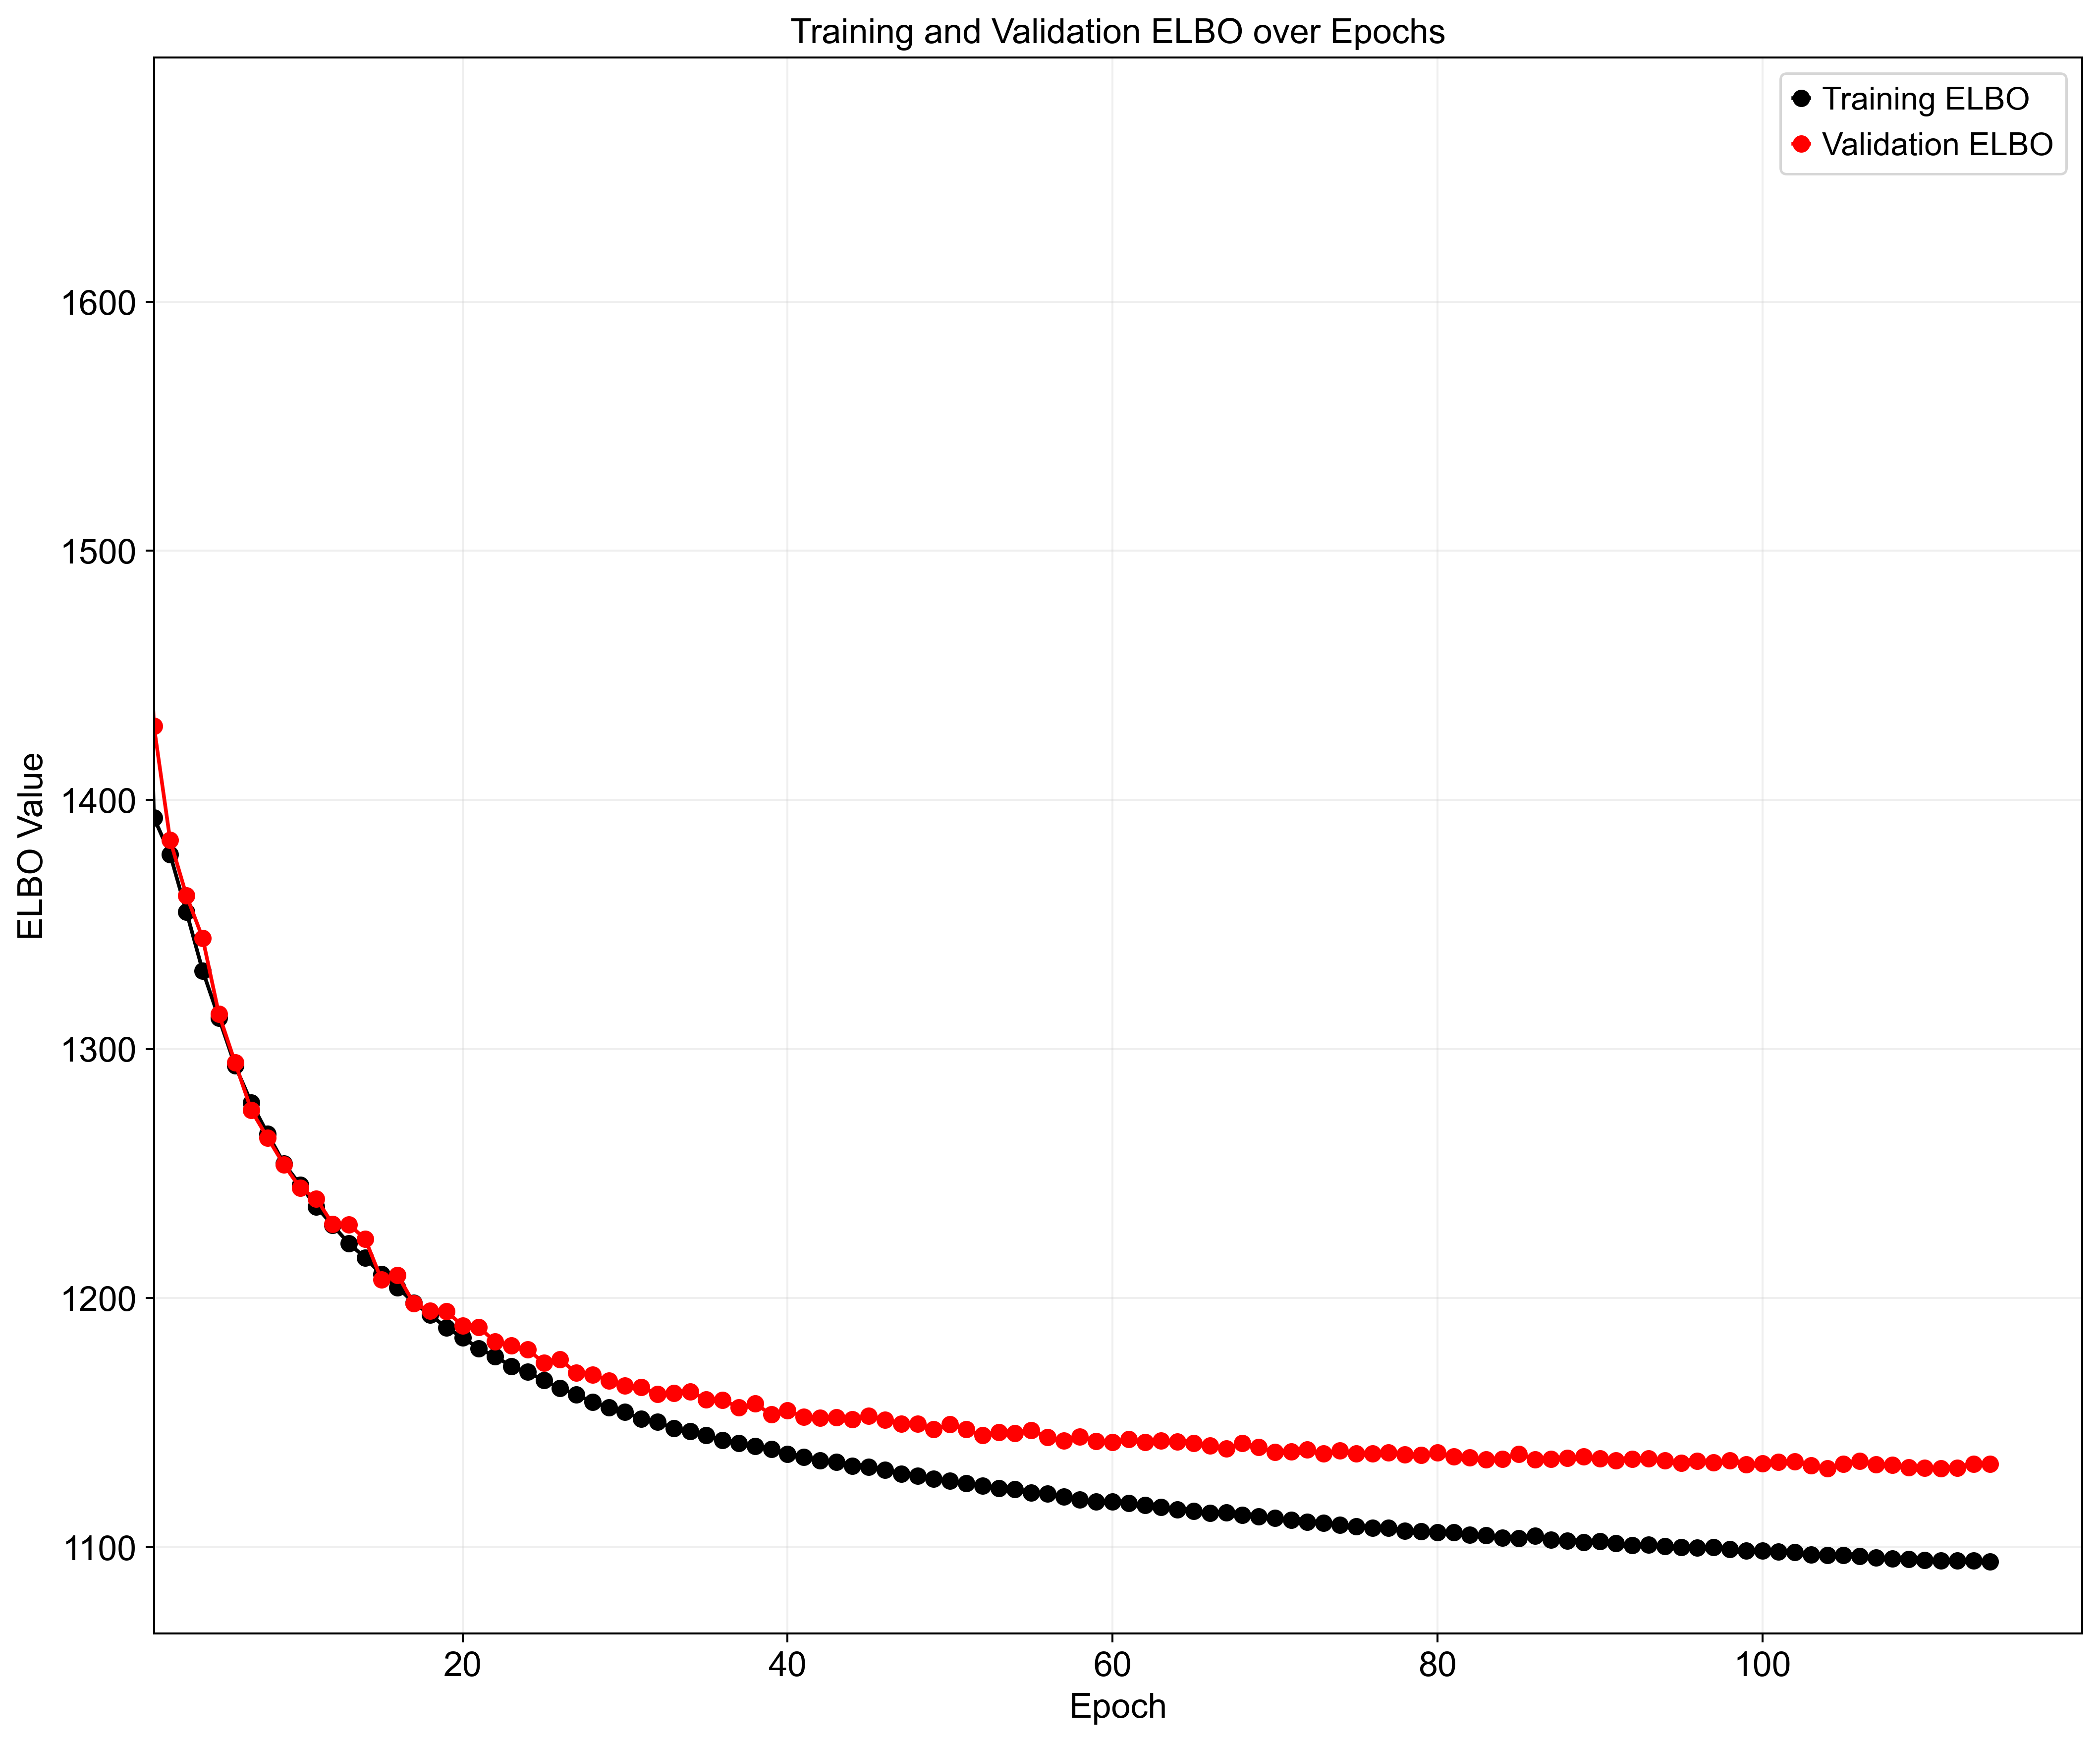

In [119]:
plt.figure(figsize=(12, 10))

plt.plot(history_df[history_df['variable'] == 'elbo_train']['epoch'], 
         history_df[history_df['variable'] == 'elbo_train']['value'], 
         color='black', marker='o', label='Training ELBO')

plt.plot(history_df[history_df['variable'] == 'elbo_validation']['epoch'],
         history_df[history_df['variable'] == 'elbo_validation']['value'], 
         color='red', marker='o', label='Validation ELBO')

plt.xlabel('Epoch')
plt.ylabel('ELBO Value')
plt.title('Training and Validation ELBO over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.xlim(left=1)

plt.tight_layout()
plt.show()

#### Label transfer with `scANVI` 

In [120]:
scanvi_model = scvi.model.SCANVI.from_scvi_model(scvi_model, 'Unknown')

In [121]:
scanvi_model.train(300, 
                     early_stopping = True,
                   check_val_every_n_epoch = 1, 
                   enable_progress_bar = True)

INFO     Training for 300 epochs.                                                                                  


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Epoch 46/300:  15%|████████████████████████▋                                                                                                                                        | 46/300 [13:51<1:16:29, 18.07s/it, v_num=1, train_loss_step=1.07e+3, train_loss_epoch=1.06e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 1128.472. Signaling Trainer to stop.


In [122]:
adata.obs["cellstates_scANVI"] = scanvi_model.predict(adata)

- Extract latent representation

In [123]:
adata.obsm["X_scANVI"] = scanvi_model.get_latent_representation(adata)

### Explore model performance using the [_Svensson_](https://www.nxn.se/valent/2023/8/10/training-scvi-posterior-predictive-distributions-over-epochs) method

In [124]:
history_df = (
    scanvi_model.history['elbo_train'].astype(float)
    .join(scanvi_model.history['elbo_validation'].astype(float))
    .reset_index()
    .melt(id_vars = ['epoch'])
)

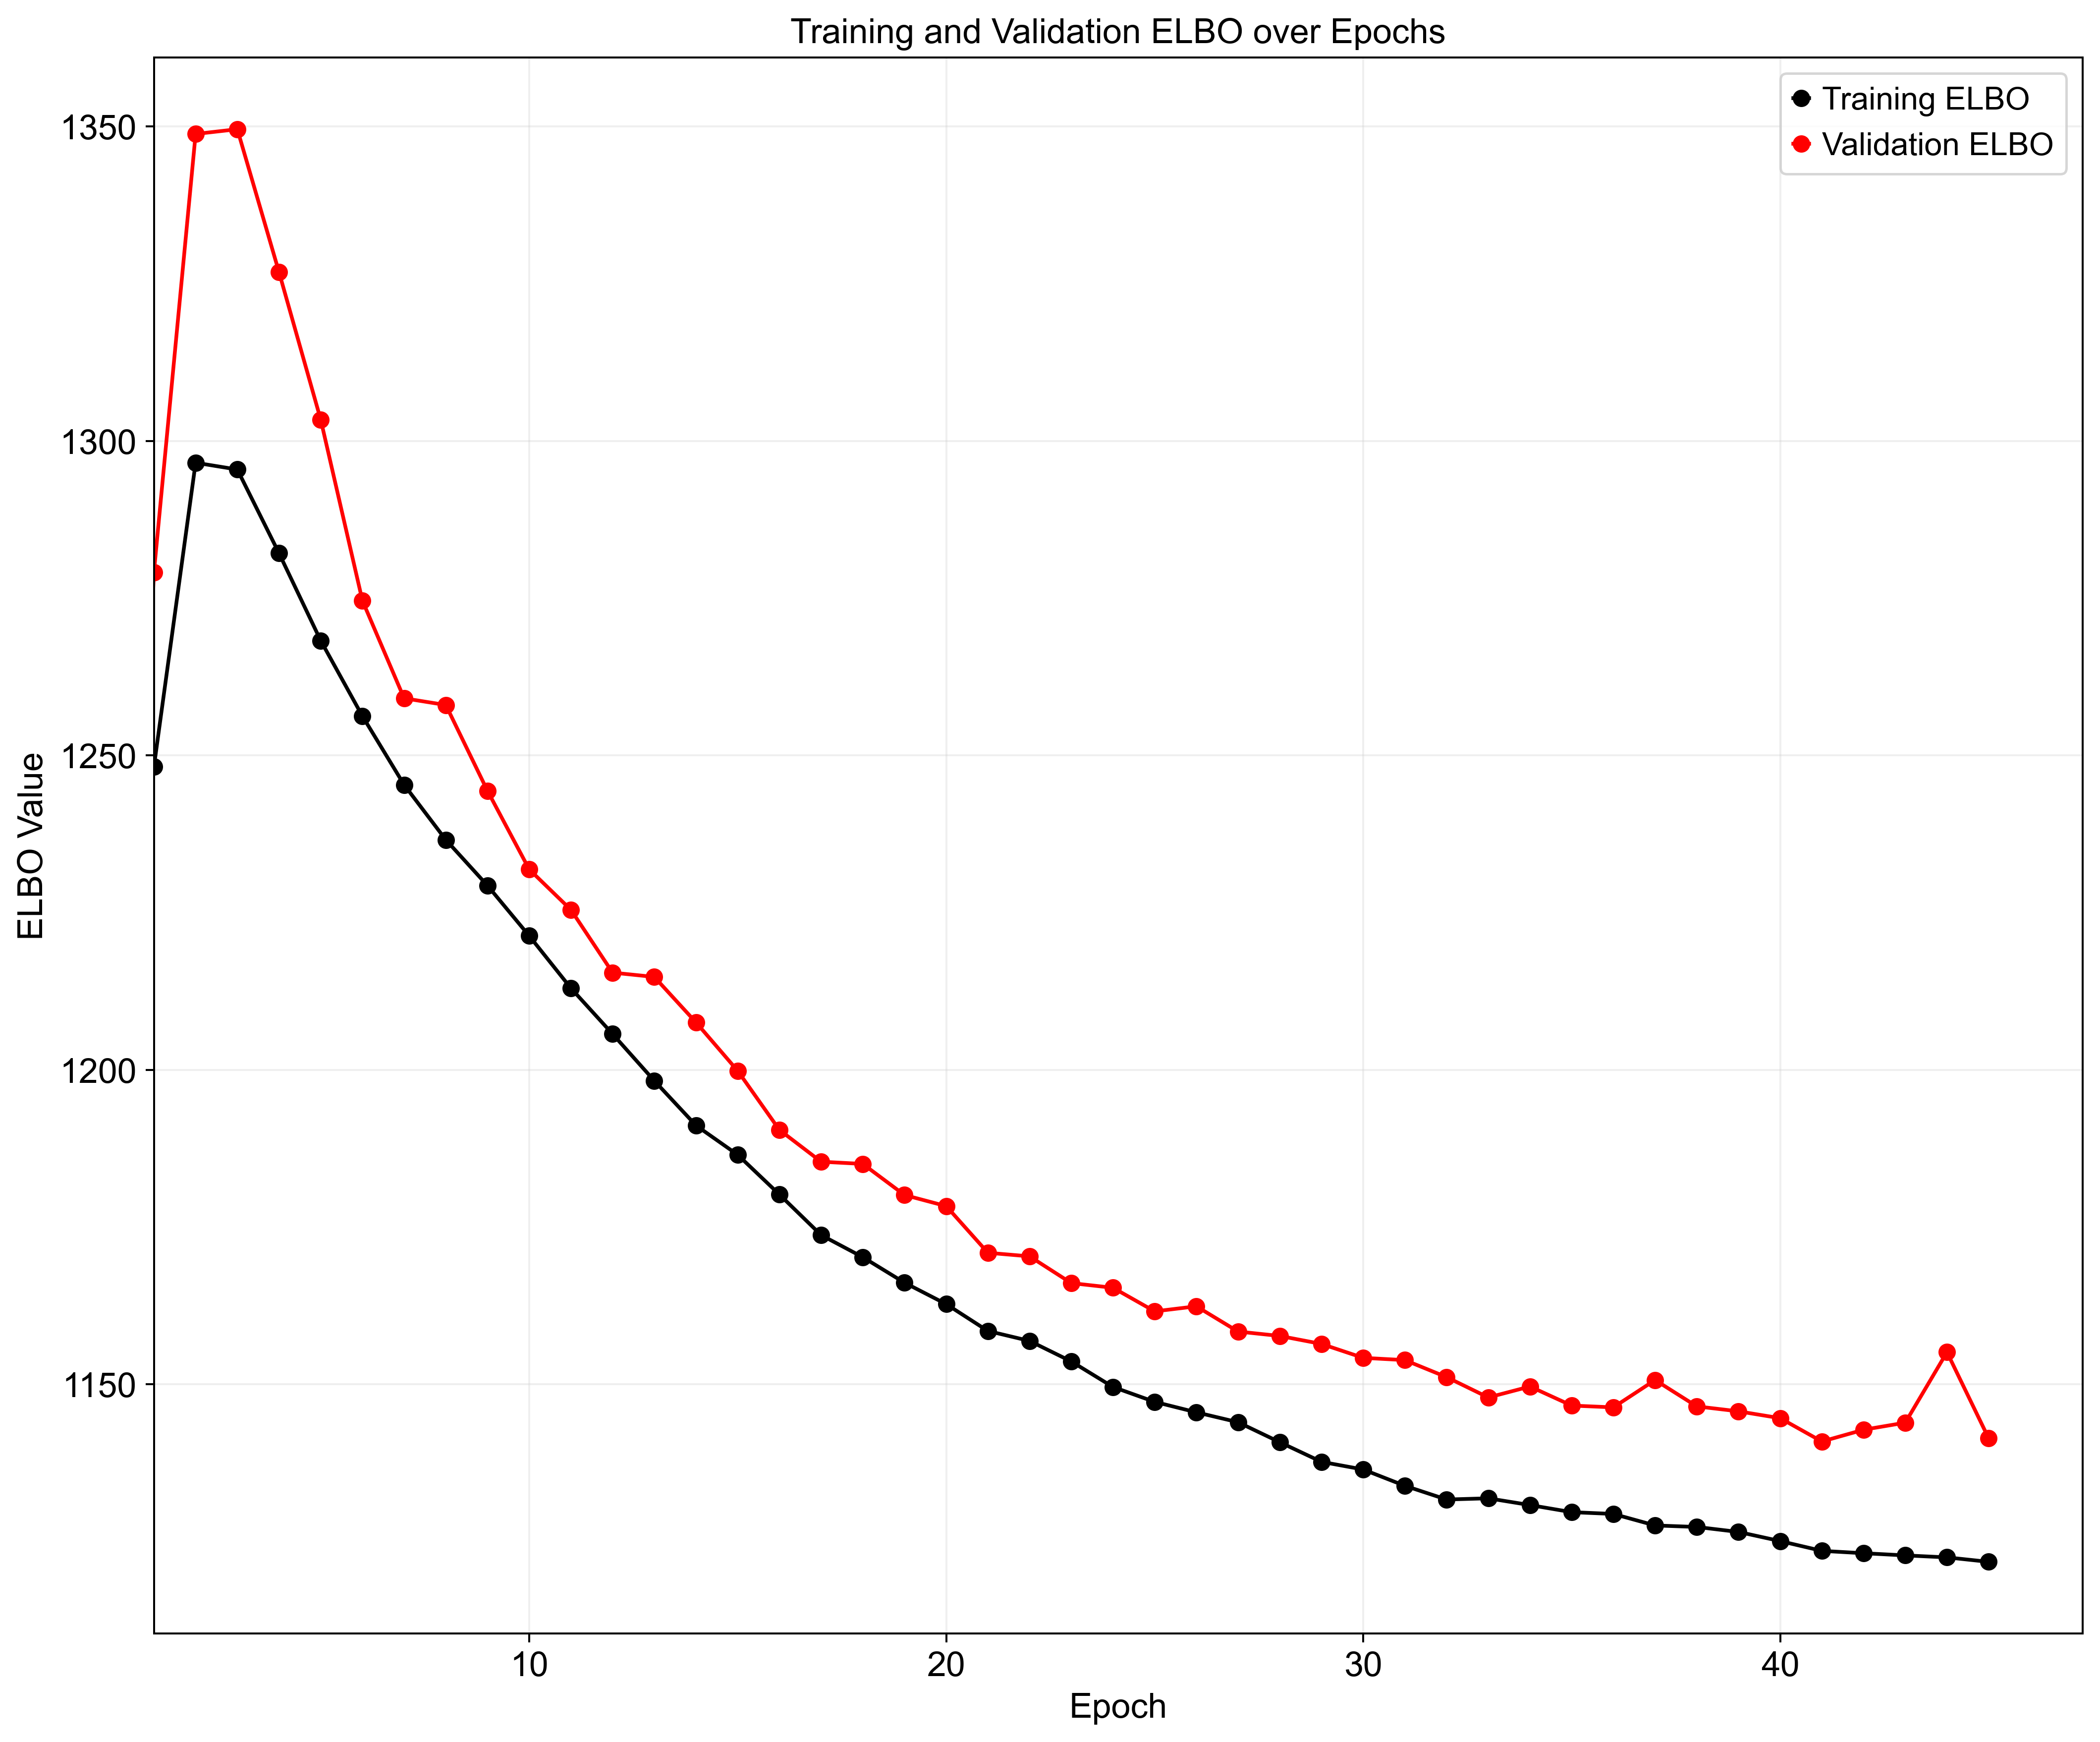

In [125]:
plt.figure(figsize=(12, 10))

plt.plot(history_df[history_df['variable'] == 'elbo_train']['epoch'], 
         history_df[history_df['variable'] == 'elbo_train']['value'], 
         color='black', marker='o', label='Training ELBO')

plt.plot(history_df[history_df['variable'] == 'elbo_validation']['epoch'],
         history_df[history_df['variable'] == 'elbo_validation']['value'], 
         color='red', marker='o', label='Validation ELBO')

plt.xlabel('Epoch')
plt.ylabel('ELBO Value')
plt.title('Training and Validation ELBO over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.xlim(left=1)

plt.tight_layout()
plt.show()

In [126]:
posterior_probs = scanvi_model.predict(adata, soft=True)

In [127]:
confidence_scores = posterior_probs.max(axis=1)

In [128]:
adata.obs['confidence_score'] = confidence_scores

+ Visualize dataset

In [129]:
sc.pp.neighbors(adata, use_rep = "X_scANVI", n_neighbors = 150, metric = 'minkowski')
sc.tl.umap(adata, min_dist = 0.6, spread = 8, random_state = 1712)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:34)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:18)


In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.umap(adata,color=["cellstates_scANVI", "confidence_score", 'cell_states', 'Integrated_05'], ncols=2, frameon=False, show=False, size = 6)
    plt.savefig(f"figures/neuronal_cellstates_transfer_categorical_values1_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(10, 10))
    sc.pl.umap(adata,color=["Study_name", "ArrayExpress_ID", 'age_group', 'organism_part', 
                            'developmental_stage', 'library_preparation_protocol', 'immunophenotype', 'developmental_stage'], ncols=4, frameon=False, show=False, size = 6)
    plt.savefig(f"figures/neuronal_cellstates_transfer_categorical_values2_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=['sex', 'Cell_cycle_phase', 'sampling_site', 'full_age', 
                            'library_construnction_and_layout', 'Protocol REF', 'Performer', 'growth_condition', 
                            'Material Type', 'donor_id'], ncols=4, frameon=False, show=False, size = 10)
    plt.savefig(f"figures/neuronal_cellstates_transfer_categorical_values3_{timestamp}.png", bbox_inches="tight")
    #plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=['n_genes', 'n_counts', 'total_counts', 'n_genes_by_counts', 'predicted_doublets', 'percent_mito', 'percent_ribo', 'percent_hb'], color_map = 'magma_r', ncols=4, frameon=False, show=False, size = 10)
    plt.savefig(f"figures/neuronal_cellstates_transfer_continues_values_{timestamp}.png", bbox_inches="tight")
    #plt.show()

## Save prepared dataset

In [140]:
adata_export= adata_raw.copy()
adata_export

AnnData object with n_obs × n_vars = 21503 × 43704
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protoco

In [141]:
adata_export.obs['cellstates_scANVI'] = adata.obs['cellstates_scANVI'].copy()
adata_export.obs['confidence_score'] = adata.obs['confidence_score'].copy()
adata_export.obsm['X_scVI'] = adata.obsm['X_scVI'].copy()
adata_export.obsm['X_scANVI'] = adata.obsm['X_scANVI'].copy()
adata_export.obsm['X_pca'] = adata.obsm['X_pca'].copy()
adata_export.obsm['umap_uncorrected'] = adata.obsm['umap_uncorrected'].copy()
adata_export.obsm['X_umap'] = adata.obsm['X_umap'].copy()

In [143]:
current_history = adata_export.uns['processing_history'].tolist()

new_entry = json.dumps({
    'timestamp': timestamp,
    'step': 'Extracted genes (7000, library_preparation_protocol - batch) that were previously captured as highly variable, merged small populations into one group, fixed bolean nan issue, deleted samples with less than 10 cells, deleted doublets, predicted neuronal cell states using scVI-scANVI, scvi params: batch = sample_id, library_construnction_and_layout,Performer and Protocol REF, n_latent = 150, n_hidden = 256, n_layers = 3, dropout_rate = 0.1, dispersion = gene-cell, gene_likelihood = nb, 115 epochs, scanvi params: 46 epochs',
})
current_history.append(new_entry)

adata_export.uns['processing_history'] = current_history

In [144]:
adata_export.obs.rename(columns={'cell_id': 'cell_index'}, inplace=True)

In [145]:
project = 'gut'
species = 'hs'
name = 'AM'
counts = 'raw'
atribute = 'all_datasets_scVI_scANVI_neuronal_cellstates'

adata_export.write_h5ad(f"data/gut_data/{project}_{species}_{atribute}_{name}_{timestamp}_{counts}.h5ad")

In [142]:
adata.obs["cellstates_scANVI"].value_counts()

cellstates_scANVI
Progenitor    7705
Branch B      6052
Branch A      3327
Neuroblast    2301
Glia          2118
Name: count, dtype: int64